# EFD Localization — Feature Engineering, Scoring, Evaluation

This Kaggle-ready notebook combines:

- `04_feature_engineering.ipynb`
- `05_localization_scoring.ipynb`
- `06_evaluation_and_visualization.ipynb`

It creates fixture-level features for every CSV scenario, computes baseline-normalized anomaly scores, ranks likely fault zones per scenario, and evaluates/visualizes the results.

**Important rule:** `faultLocation` and `faultResistance` are used only for baseline selection and final evaluation. They are **not** used as prediction inputs for faulted scenarios.


## 0. Imports and Kaggle paths

Run after attaching your Kaggle dataset containing `EFD_T0001`, `EFD_T0002`, and `EFD_T0003`. Outputs are saved to `/kaggle/working/outputs` and plots to `/kaggle/working/plots`.


In [1]:
from pathlib import Path
import os, csv, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

warnings.filterwarnings("ignore")

INPUT_ROOT = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")
OUTPUTS_DIR = WORKING_ROOT / "outputs"
PLOTS_DIR = WORKING_ROOT / "plots"
PRED_PLOTS_DIR = PLOTS_DIR / "predictions"
EVAL_PLOTS_DIR = PLOTS_DIR / "evaluation"

for d in [OUTPUTS_DIR, PLOTS_DIR, PRED_PLOTS_DIR, EVAL_PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Available Kaggle input folders:")
for p in INPUT_ROOT.iterdir():
    print(" -", p)


Available Kaggle input folders:
 - /kaggle/input/datasets


## 1. Detect data folder and build metadata

The notebook automatically searches for the folder containing `EFD_T0001`, `EFD_T0002`, and `EFD_T0003`.


In [2]:
def detect_data_root(input_root=INPUT_ROOT):
    candidates = []
    for p in input_root.rglob("*"):
        if p.is_dir():
            child_names = {child.name for child in p.iterdir() if child.is_dir()}
            if {"EFD_T0001", "EFD_T0002", "EFD_T0003"}.issubset(child_names):
                candidates.append(p)
    if candidates:
        return candidates[0]

    scored = []
    for p in input_root.rglob("*"):
        if p.is_dir():
            n = len(list(p.rglob("*.csv")))
            if n > 0:
                scored.append((n, p))
    if scored:
        return sorted(scored, reverse=True)[0][1]
    raise FileNotFoundError("Could not detect EFD data root. Check attached Kaggle dataset.")

DATA_ROOT = detect_data_root()
csv_files = sorted(DATA_ROOT.rglob("*.csv"))

print("DATA_ROOT:", DATA_ROOT)
print("CSV files found:", len(csv_files))
for f in csv_files[:5]:
    print(" -", f)


DATA_ROOT: /kaggle/input/datasets/apubhowmick2/efd-dataset
CSV files found: 80
 - /kaggle/input/datasets/apubhowmick2/efd-dataset/EFD_T0001/1776350717-7-1-0-0.csv
 - /kaggle/input/datasets/apubhowmick2/efd-dataset/EFD_T0001/1776351640-7-1-1-0.csv
 - /kaggle/input/datasets/apubhowmick2/efd-dataset/EFD_T0001/1776352564-7-1-1-1.csv
 - /kaggle/input/datasets/apubhowmick2/efd-dataset/EFD_T0001/1776353487-7-1-1-2.csv
 - /kaggle/input/datasets/apubhowmick2/efd-dataset/EFD_T0001/1776354410-7-1-1-4.csv


In [3]:
def parse_filename_metadata(file_path: Path) -> dict:
    # Filename format: <epoch>-<commCh>-<powerStep>-<faultLocation>-<faultResistance>.csv
    # faultLocation and faultResistance are labels; they are not model inputs.
    parts = file_path.stem.split("-")
    if len(parts) != 5:
        raise ValueError(f"Unexpected filename format: {file_path.name}")
    epoch, comm_ch, power_step, fault_location, fault_resistance = parts
    return {
        "file_path": str(file_path),
        "file_name": file_path.name,
        "run_id": file_path.parent.name,
        "epoch": int(epoch),
        "commCh": int(comm_ch),
        "powerStep": int(power_step),
        "faultLocation": int(fault_location),       # label only
        "faultResistance": int(fault_resistance),   # label only
    }

metadata_df = pd.DataFrame([parse_filename_metadata(p) for p in csv_files])
metadata_df.to_csv(OUTPUTS_DIR / "metadata.csv", index=False)
print(metadata_df.shape)
metadata_df.head()


(80, 8)


,file_path,file_name,run_id,epoch,commCh,powerStep,faultLocation,faultResistance
0,/kaggle/input/datasets/apubhowmick2/efd-datase...,1776350717-7-1-0-0.csv,EFD_T0001,1776350717,7,1,0,0
1,/kaggle/input/datasets/apubhowmick2/efd-datase...,1776351640-7-1-1-0.csv,EFD_T0001,1776351640,7,1,1,0
2,/kaggle/input/datasets/apubhowmick2/efd-datase...,1776352564-7-1-1-1.csv,EFD_T0001,1776352564,7,1,1,1
3,/kaggle/input/datasets/apubhowmick2/efd-datase...,1776353487-7-1-1-2.csv,EFD_T0001,1776353487,7,1,1,2
4,/kaggle/input/datasets/apubhowmick2/efd-datase...,1776354410-7-1-1-4.csv,EFD_T0001,1776354410,7,1,1,4


## 2. Message schemas and CSV parser

Each raw CSV has mixed row types, so rows must be split by message type before assigning column names.


In [4]:
COMM_COLUMNS = [
    "timestamp", "message_type", "remote_id", "response_rate", "num_attempts", "num_failures",
    "ds_avg_repeater_depth", "us_avg_repeater_depth", "ds_current_repeater_depth", "us_current_repeater_depth",
    "avg_receive_signal_strength", "incorrect_count",
]
RATES_COLUMNS = [
    "timestamp", "message_type", "remote_id",
    "dsRawRate0", "dsRawRate1", "dsRawRate2", "dsRawRate3", "dsRawRate4", "dsRawRate5", "dsRawRate6", "dsRawRate7",
    "usRawRate0", "usRawRate1", "usRawRate2", "usRawRate3", "usRawRate4", "usRawRate5", "usRawRate6", "usRawRate7",
]
EXCOMM_COLUMNS = [
    "timestamp", "message_type", "remote_id", "peakInputLevel", "overflowStatus", "berCount", "phaseNoise_dB", "rxCrcFailCount",
]
CORR_COLUMNS = [
    "timestamp", "message_type", "remote_id", "peakCorrLevel_dB", "peakUncorrLevel_dB",
    "ftryCorrTrigCount", "userCorrTrigCount", "corrFired", "ftryCorrFired",
]
SCHEMAS = {"COMM": COMM_COLUMNS, "RATES": RATES_COLUMNS, "EXCOMM": EXCOMM_COLUMNS, "CORR": CORR_COLUMNS}
EXPECTED_COL_COUNTS = {"COMM": 12, "RATES": 19, "EXCOMM": 8, "CORR": 9}
MESSAGE_TYPES = ["COMM", "RATES", "EXCOMM", "CORR"]


def parse_efd_csv(file_path: Path):
    rows_by_type = {msg_type: [] for msg_type in MESSAGE_TYPES}
    malformed_rows = []
    with open(file_path, "r", newline="") as f:
        reader = csv.reader(f)
        for line_number, row in enumerate(reader, start=1):
            row = [x.strip() for x in row]
            if len(row) < 2:
                malformed_rows.append({"line_number": line_number, "reason": "too_few_columns", "row_length": len(row)})
                continue
            msg_type = row[1]
            if msg_type not in MESSAGE_TYPES:
                malformed_rows.append({"line_number": line_number, "reason": "unknown_message_type", "row_length": len(row), "message_type": msg_type})
                continue
            expected = EXPECTED_COL_COUNTS[msg_type]
            if len(row) != expected:
                malformed_rows.append({"line_number": line_number, "reason": "wrong_column_count", "row_length": len(row), "expected": expected, "message_type": msg_type})
                continue
            rows_by_type[msg_type].append(row)

    dfs = {}
    for msg_type, rows in rows_by_type.items():
        df = pd.DataFrame(rows, columns=SCHEMAS[msg_type])
        if not df.empty:
            for col in df.columns:
                if col != "message_type":
                    df[col] = pd.to_numeric(df[col], errors="coerce")
            df["remote_id"] = df["remote_id"].astype("Int64")
        dfs[msg_type] = df
    return dfs, pd.DataFrame(malformed_rows)

sample_dfs, sample_malformed = parse_efd_csv(csv_files[0])
for k, v in sample_dfs.items():
    print(k, v.shape)
print("Malformed rows in sample:", len(sample_malformed))


COMM (8280, 12)
RATES (8280, 19)
EXCOMM (1796, 8)
CORR (1796, 9)
Malformed rows in sample: 1


## 3. Feature engineering

For every CSV scenario and every fixture, create one fixture-level feature row. These fixture-level rows are intermediate evidence; final predictions are scenario-level.


In [5]:
def safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    return np.where(denominator == 0, 0, numerator / denominator)


def aggregate_comm(comm_df):
    if comm_df.empty:
        return pd.DataFrame(columns=["remote_id"])
    g = comm_df.groupby("remote_id")
    out = pd.DataFrame({
        "response_rate_mean": g["response_rate"].mean(),
        "response_rate_min": g["response_rate"].min(),
        "response_rate_std": g["response_rate"].std().fillna(0),
        "num_attempts_mean": g["num_attempts"].mean(),
        "num_attempts_sum": g["num_attempts"].sum(),
        "num_failures_sum": g["num_failures"].sum(),
        "ds_avg_repeater_depth_mean": g["ds_avg_repeater_depth"].mean(),
        "us_avg_repeater_depth_mean": g["us_avg_repeater_depth"].mean(),
        "ds_current_repeater_depth_mean": g["ds_current_repeater_depth"].mean(),
        "us_current_repeater_depth_mean": g["us_current_repeater_depth"].mean(),
        "avg_receive_signal_strength_mean": g["avg_receive_signal_strength"].mean(),
        "avg_receive_signal_strength_std": g["avg_receive_signal_strength"].std().fillna(0),
        "incorrect_count_sum": g["incorrect_count"].sum(),
    }).reset_index()
    out["failure_rate"] = safe_divide(out["num_failures_sum"], out["num_attempts_sum"])
    return out.drop(columns=["num_attempts_sum"])


def aggregate_rates(rates_df):
    if rates_df.empty:
        return pd.DataFrame(columns=["remote_id"])
    rate_cols = [f"dsRawRate{k}" for k in range(8)] + [f"usRawRate{k}" for k in range(8)]
    out = rates_df.groupby("remote_id")[rate_cols].mean().reset_index()
    out = out.rename(columns={c: f"{c}_mean" for c in rate_cols})

    ds_cols = [f"dsRawRate{k}_mean" for k in range(8)]
    us_cols = [f"usRawRate{k}_mean" for k in range(8)]
    ds_sum = out[ds_cols].sum(axis=1)
    us_sum = out[us_cols].sum(axis=1)
    ds_higher = out[ds_cols[1:]].sum(axis=1)
    us_higher = out[us_cols[1:]].sum(axis=1)

    out["higher_depth_usage_ds"] = safe_divide(ds_higher, ds_sum)
    out["higher_depth_usage_us"] = safe_divide(us_higher, us_sum)
    out["weighted_avg_depth_ds"] = safe_divide(sum(k * out[f"dsRawRate{k}_mean"] for k in range(8)), ds_sum)
    out["weighted_avg_depth_us"] = safe_divide(sum(k * out[f"usRawRate{k}_mean"] for k in range(8)), us_sum)

    def max_nonzero(row, prefix):
        vals = [row[f"{prefix}RawRate{k}_mean"] for k in range(8)]
        nz = [k for k, v in enumerate(vals) if pd.notna(v) and v > 0]
        return max(nz) if nz else 0

    out["max_nonzero_depth_ds"] = out.apply(lambda r: max_nonzero(r, "ds"), axis=1)
    out["max_nonzero_depth_us"] = out.apply(lambda r: max_nonzero(r, "us"), axis=1)
    out["ds_us_asymmetry"] = out["weighted_avg_depth_ds"] - out["weighted_avg_depth_us"]
    return out[["remote_id", "dsRawRate0_mean", "usRawRate0_mean", "higher_depth_usage_ds", "higher_depth_usage_us",
                "weighted_avg_depth_ds", "weighted_avg_depth_us", "max_nonzero_depth_ds", "max_nonzero_depth_us", "ds_us_asymmetry"]]


def aggregate_excomm(excomm_df):
    if excomm_df.empty:
        return pd.DataFrame(columns=["remote_id"])
    g = excomm_df.groupby("remote_id")
    return pd.DataFrame({
        "peakInputLevel_mean": g["peakInputLevel"].mean(),
        "peakInputLevel_std": g["peakInputLevel"].std().fillna(0),
        "overflowStatus_nonzero_count": g["overflowStatus"].apply(lambda s: (s.fillna(0) != 0).sum()),
        "berCount_sum": g["berCount"].sum(),
        "berCount_mean": g["berCount"].mean(),
        "phaseNoise_dB_mean": g["phaseNoise_dB"].mean(),
        "phaseNoise_dB_std": g["phaseNoise_dB"].std().fillna(0),
        "rxCrcFailCount_sum": g["rxCrcFailCount"].sum(),
        "rxCrcFailCount_mean": g["rxCrcFailCount"].mean(),
    }).reset_index()


def aggregate_corr(corr_df):
    if corr_df.empty:
        return pd.DataFrame(columns=["remote_id"])
    g = corr_df.groupby("remote_id")
    out = pd.DataFrame({
        "peakCorrLevel_dB_mean": g["peakCorrLevel_dB"].mean(),
        "peakUncorrLevel_dB_mean": g["peakUncorrLevel_dB"].mean(),
        "ftryCorrTrigCount_mean": g["ftryCorrTrigCount"].mean(),
        "userCorrTrigCount_mean": g["userCorrTrigCount"].mean(),
        "corrFired_rate": g["corrFired"].mean(),
        "ftryCorrFired_rate": g["ftryCorrFired"].mean(),
    }).reset_index()
    out["snr_proxy"] = out["peakCorrLevel_dB_mean"] - out["peakUncorrLevel_dB_mean"]
    return out


def build_features_for_file(file_path: Path):
    dfs, malformed = parse_efd_csv(file_path)
    base = pd.DataFrame({"remote_id": range(1001, 1091)})
    out = base.merge(aggregate_comm(dfs["COMM"]), on="remote_id", how="left")
    out = out.merge(aggregate_rates(dfs["RATES"]), on="remote_id", how="left")
    out = out.merge(aggregate_excomm(dfs["EXCOMM"]), on="remote_id", how="left")
    out = out.merge(aggregate_corr(dfs["CORR"]), on="remote_id", how="left")
    meta = parse_filename_metadata(file_path)
    for k, v in meta.items():
        out[k] = v
    return out


In [6]:
feature_rows = []
for i, file_path in enumerate(csv_files, start=1):
    if i % 10 == 0 or i == 1:
        print(f"Feature engineering {i}/{len(csv_files)}: {file_path.name}")
    feature_rows.append(build_features_for_file(file_path))

fixture_features = pd.concat(feature_rows, ignore_index=True)
id_cols = ["file_name", "file_path", "run_id", "epoch", "commCh", "powerStep", "faultLocation", "faultResistance", "remote_id"]
feature_cols = [c for c in fixture_features.columns if c not in id_cols]
fixture_features = fixture_features[id_cols + feature_cols]
fixture_features.to_csv(OUTPUTS_DIR / "fixture_features.csv", index=False)
print("fixture_features shape:", fixture_features.shape)
fixture_features.head()


Feature engineering 1/80: 1776350717-7-1-0-0.csv
Feature engineering 10/80: 1776359027-7-1-2-2.csv
Feature engineering 20/80: 1776368262-7-1-4-0.csv
Feature engineering 30/80: 1776456069-7-1-1-8.csv
Feature engineering 40/80: 1776465304-7-1-3-2.csv
Feature engineering 50/80: 1776714780-7-1-1-0.csv
Feature engineering 60/80: 1776724015-7-1-2-2.csv
Feature engineering 70/80: 1776733250-7-1-3-4.csv
Feature engineering 80/80: 1776742486-7-1-4-8.csv
fixture_features shape: (7200, 47)


,file_name,file_path,run_id,epoch,commCh,powerStep,faultLocation,faultResistance,remote_id,response_rate_mean,...,phaseNoise_dB_std,rxCrcFailCount_sum,rxCrcFailCount_mean,peakCorrLevel_dB_mean,peakUncorrLevel_dB_mean,ftryCorrTrigCount_mean,userCorrTrigCount_mean,corrFired_rate,ftryCorrFired_rate,snr_proxy
0,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1001,100.0,...,4.702397,0,0.0,13.556836,100.576953,0.0,26133.15,1.0,0.0,-87.020117
1,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1002,100.0,...,1.911127,0,0.0,13.550586,99.800781,0.0,26185.95,1.0,0.0,-86.250195
2,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1003,100.0,...,3.714630,0,0.0,13.524023,99.284766,0.0,26230.65,1.0,0.0,-85.760742
3,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1004,100.0,...,4.077466,0,0.0,13.509375,98.654687,0.0,26280.25,1.0,0.0,-85.145312
4,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1005,100.0,...,1.303593,0,0.0,13.504102,98.380078,0.0,26330.05,1.0,0.0,-84.875977


## 4. Baseline statistics

No-fault files (`faultLocation = 0`) define healthy behavior. Baseline statistics are computed per run, fixture, and feature.


In [7]:
ID_COLS = ["file_name", "file_path", "run_id", "epoch", "commCh", "powerStep", "faultLocation", "faultResistance", "remote_id"]
FEATURE_COLS = [c for c in fixture_features.columns if c not in ID_COLS]

baseline_source = fixture_features[fixture_features["faultLocation"] == 0].copy()
print("Baseline fixture rows:", baseline_source.shape)

baseline_stats = baseline_source.groupby(["run_id", "remote_id"])[FEATURE_COLS].agg(["mean", "std", "median"])
baseline_stats.columns = [f"{feat}_baseline_{stat}" for feat, stat in baseline_stats.columns]
baseline_stats = baseline_stats.reset_index()
for c in baseline_stats.columns:
    if c.endswith("_baseline_std"):
        baseline_stats[c] = baseline_stats[c].replace(0, np.nan)

baseline_stats.to_csv(OUTPUTS_DIR / "baseline_stats.csv", index=False)
print("baseline_stats shape:", baseline_stats.shape)
baseline_stats.head()


Baseline fixture rows: (1080, 47)
baseline_stats shape: (270, 116)


,run_id,remote_id,response_rate_mean_baseline_mean,response_rate_mean_baseline_std,response_rate_mean_baseline_median,response_rate_min_baseline_mean,response_rate_min_baseline_std,response_rate_min_baseline_median,response_rate_std_baseline_mean,response_rate_std_baseline_std,...,userCorrTrigCount_mean_baseline_median,corrFired_rate_baseline_mean,corrFired_rate_baseline_std,corrFired_rate_baseline_median,ftryCorrFired_rate_baseline_mean,ftryCorrFired_rate_baseline_std,ftryCorrFired_rate_baseline_median,snr_proxy_baseline_mean,snr_proxy_baseline_std,snr_proxy_baseline_median
0,EFD_T0001,1001,99.193548,1.029492,99.462366,50.0,57.735027,50.0,6.238578,7.406387,...,27140.891667,1.0,NaN,1.0,0.0,NaN,0.0,-87.004774,0.044057,-87.001270
1,EFD_T0001,1002,99.193548,1.029492,99.462366,50.0,57.735027,50.0,6.238578,7.406387,...,27191.028571,1.0,NaN,1.0,0.0,NaN,0.0,-86.322652,0.100168,-86.306250
2,EFD_T0001,1003,99.193548,1.029492,99.462366,50.0,57.735027,50.0,6.238578,7.406387,...,27239.036905,1.0,NaN,1.0,0.0,NaN,0.0,-85.818573,0.072322,-85.800488
3,EFD_T0001,1004,99.193548,1.029492,99.462366,50.0,57.735027,50.0,6.238578,7.406387,...,27287.951190,1.0,NaN,1.0,0.0,NaN,0.0,-85.191160,0.052301,-85.185542
4,EFD_T0001,1005,99.193548,1.029492,99.462366,50.0,57.735027,50.0,6.238578,7.406387,...,27335.782143,1.0,NaN,1.0,0.0,NaN,0.0,-84.800728,0.096896,-84.817090


## 5. Z-scores and direction-aware anomaly scores

All anomaly scores are capped at 5 and interpreted as: **higher = more suspicious**.


In [8]:
HIGHER_IS_WORSE = {
    "response_rate_std", "num_failures_sum", "failure_rate", "ds_avg_repeater_depth_mean", "us_avg_repeater_depth_mean",
    "ds_current_repeater_depth_mean", "us_current_repeater_depth_mean", "incorrect_count_sum",
    "higher_depth_usage_ds", "higher_depth_usage_us", "weighted_avg_depth_ds", "weighted_avg_depth_us",
    "max_nonzero_depth_ds", "max_nonzero_depth_us", "overflowStatus_nonzero_count", "berCount_sum", "berCount_mean",
    "phaseNoise_dB_mean", "phaseNoise_dB_std", "rxCrcFailCount_sum", "rxCrcFailCount_mean",
    "peakUncorrLevel_dB_mean", "ftryCorrTrigCount_mean", "userCorrTrigCount_mean",
}
LOWER_IS_WORSE = {
    "response_rate_mean", "response_rate_min", "avg_receive_signal_strength_mean", "dsRawRate0_mean", "usRawRate0_mean",
    "peakInputLevel_mean", "peakCorrLevel_dB_mean", "snr_proxy",
}
FEATURE_DIRECTION = {f: ("higher" if f in HIGHER_IS_WORSE else "lower" if f in LOWER_IS_WORSE else "absolute") for f in FEATURE_COLS}
print(pd.Series(FEATURE_DIRECTION).value_counts())


def compute_anomaly_scores(fixture_features, baseline_stats, cap=5.0, epsilon=1e-6):
    merged = fixture_features.merge(baseline_stats, on=["run_id", "remote_id"], how="left")
    global_baseline = fixture_features[fixture_features["faultLocation"] == 0].groupby("remote_id")[FEATURE_COLS].agg(["mean", "std"])
    global_baseline.columns = [f"{feat}_global_{stat}" for feat, stat in global_baseline.columns]
    global_baseline = global_baseline.reset_index()
    merged = merged.merge(global_baseline, on="remote_id", how="left")
    out = merged[ID_COLS].copy()

    for feat in FEATURE_COLS:
        base_mean = merged[f"{feat}_baseline_mean"].fillna(merged[f"{feat}_global_mean"])
        base_std = merged[f"{feat}_baseline_std"].fillna(merged[f"{feat}_global_std"]).replace(0, np.nan).fillna(epsilon).clip(lower=epsilon)
        z = ((merged[feat] - base_mean) / base_std).replace([np.inf, -np.inf], np.nan).fillna(0)
        direction = FEATURE_DIRECTION.get(feat, "absolute")
        if direction == "higher":
            score = z.clip(lower=0)
        elif direction == "lower":
            score = (-z).clip(lower=0)
        else:
            score = z.abs()
        out[f"{feat}_z"] = z
        out[f"{feat}_anom"] = score.clip(upper=cap)
    return out

fixture_anomaly_scores = compute_anomaly_scores(fixture_features, baseline_stats)
fixture_anomaly_scores.to_csv(OUTPUTS_DIR / "fixture_anomaly_scores.csv", index=False)
print("fixture_anomaly_scores shape:", fixture_anomaly_scores.shape)
fixture_anomaly_scores.head()


higher      24
lower        8
absolute     6
Name: count, dtype: int64
fixture_anomaly_scores shape: (7200, 85)


,file_name,file_path,run_id,epoch,commCh,powerStep,faultLocation,faultResistance,remote_id,response_rate_mean_z,...,ftryCorrTrigCount_mean_z,ftryCorrTrigCount_mean_anom,userCorrTrigCount_mean_z,userCorrTrigCount_mean_anom,corrFired_rate_z,corrFired_rate_anom,ftryCorrFired_rate_z,ftryCorrFired_rate_anom,snr_proxy_z,snr_proxy_anom
0,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1001,0.783349,...,0.0,0.0,-0.901262,0.0,0.0,0.0,0.0,0.0,-0.348269,0.348269
1,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1002,0.783349,...,0.0,0.0,-0.900202,0.0,0.0,0.0,0.0,0.0,0.723349,0.000000
2,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1003,0.783349,...,0.0,0.0,-0.900910,0.0,0.0,0.0,0.0,0.0,0.799634,0.000000
3,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1004,0.783349,...,0.0,0.0,-0.900894,0.0,0.0,0.0,0.0,0.0,0.876610,0.000000
4,1776350717-7-1-0-0.csv,/kaggle/input/datasets/apubhowmick2/efd-datase...,EFD_T0001,1776350717,7,1,0,0,1005,0.783349,...,0.0,0.0,-0.900114,0.0,0.0,0.0,0.0,0.0,-0.776594,0.776594


## 6. Localization scoring

Produces exactly one scenario-level prediction record per CSV. Labels are not used by the prediction function.


In [9]:
COMM_FEATURES = ["response_rate_mean", "response_rate_min", "response_rate_std", "num_attempts_mean", "num_failures_sum", "failure_rate", "ds_avg_repeater_depth_mean", "us_avg_repeater_depth_mean", "ds_current_repeater_depth_mean", "us_current_repeater_depth_mean", "avg_receive_signal_strength_mean", "avg_receive_signal_strength_std", "incorrect_count_sum"]
RATES_FEATURES = ["dsRawRate0_mean", "usRawRate0_mean", "higher_depth_usage_ds", "higher_depth_usage_us", "weighted_avg_depth_ds", "weighted_avg_depth_us", "max_nonzero_depth_ds", "max_nonzero_depth_us", "ds_us_asymmetry"]
EXCOMM_FEATURES = ["peakInputLevel_mean", "peakInputLevel_std", "overflowStatus_nonzero_count", "berCount_sum", "berCount_mean", "phaseNoise_dB_mean", "phaseNoise_dB_std", "rxCrcFailCount_sum", "rxCrcFailCount_mean"]
CORR_FEATURES = ["peakCorrLevel_dB_mean", "peakUncorrLevel_dB_mean", "snr_proxy", "ftryCorrTrigCount_mean", "userCorrTrigCount_mean", "corrFired_rate", "ftryCorrFired_rate"]
FAMILY_FEATURES = {"COMM": COMM_FEATURES, "RATES": RATES_FEATURES, "EXCOMM": EXCOMM_FEATURES, "CORR": CORR_FEATURES}
FAMILY_WEIGHTS = {"COMM": 0.25, "RATES": 0.25, "EXCOMM": 0.25, "CORR": 0.25}


def add_family_scores(df):
    out = df.copy()
    for family, feats in FAMILY_FEATURES.items():
        cols = [f"{feat}_anom" for feat in feats if f"{feat}_anom" in out.columns]
        out[f"{family}_score"] = out[cols].mean(axis=1) if cols else 0.0
    weighted = np.zeros(len(out))
    for family, w in FAMILY_WEIGHTS.items():
        weighted += w * out[f"{family}_score"].fillna(0).values
    out["combined_fixture_score"] = weighted / sum(FAMILY_WEIGHTS.values())
    return out

scored_fixture_df = add_family_scores(fixture_anomaly_scores)
scored_fixture_df.to_csv(OUTPUTS_DIR / "scored_fixture_anomalies.csv", index=False)
scored_fixture_df[["file_name", "remote_id", "COMM_score", "RATES_score", "EXCOMM_score", "CORR_score", "combined_fixture_score"]].head()


,file_name,remote_id,COMM_score,RATES_score,EXCOMM_score,CORR_score,combined_fixture_score
0,1776350717-7-1-0-0.csv,1001,0.068911,0.000000,0.190538,0.216020,0.118867
1,1776350717-7-1-0-0.csv,1002,0.277356,0.000000,0.084786,0.000000,0.090536
2,1776350717-7-1-0-0.csv,1003,0.065275,0.000000,0.102786,0.041142,0.052301
3,1776350717-7-1-0-0.csv,1004,0.069357,0.000000,0.155409,0.017322,0.060522
4,1776350717-7-1-0-0.csv,1005,0.063666,0.333333,0.352433,0.225076,0.243627


In [10]:
def contiguous_regions(mask):
    regions, start = [], None
    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            regions.append((start, i - 1))
            start = None
    if start is not None:
        regions.append((start, len(mask) - 1))
    return regions


def top_supporting_metrics_for_zone(scenario_scores, start_id, end_id, top_n=5):
    zone = scenario_scores[(scenario_scores["remote_id"] >= start_id) & (scenario_scores["remote_id"] <= end_id)]
    anom_cols = [c for c in zone.columns if c.endswith("_anom")]
    if not anom_cols or zone.empty:
        return []
    vals = zone[anom_cols].mean().sort_values(ascending=False).head(top_n)
    return [c.replace("_anom", "") for c in vals.index]


def family_agreement(zone):
    family_scores = {fam: zone[f"{fam}_score"].mean() for fam in FAMILY_FEATURES}
    active = [fam for fam, score in family_scores.items() if score >= 1.0]
    return len(active), family_scores


def assign_confidence(zone_score, sharpness, agreement_count, is_no_fault_candidate=False):
    if is_no_fault_candidate:
        return "Uncertain"
    if zone_score >= 2.5 and sharpness >= 0.8 and agreement_count >= 3:
        return "High"
    if zone_score >= 1.5 and agreement_count >= 2:
        return "Medium"
    if zone_score >= 0.8 and agreement_count >= 1:
        return "Low"
    return "Uncertain"


def predict_scenario(scenario_df, window=7, top_k=3):
    df = scenario_df.sort_values("remote_id").copy()
    df["smoothed_score"] = df["combined_fixture_score"].rolling(window=window, center=True, min_periods=1).mean()
    df["gradient_abs"] = df["smoothed_score"].diff().abs().fillna(0)

    max_score = df["smoothed_score"].max()
    threshold = max(0.75, df["smoothed_score"].quantile(0.75))
    mask = df["smoothed_score"] >= threshold
    candidates = []

    for s, e in contiguous_regions(mask.tolist()):
        region = df.iloc[s:e+1]
        if len(region) < 2 and region["smoothed_score"].mean() < 2.0:
            continue
        start_id = int(region["remote_id"].min())
        end_id = int(region["remote_id"].max())
        zone_score = float(region["smoothed_score"].mean())
        zone_peak = float(region["smoothed_score"].max())
        sharpness = float(max(df.loc[max(s-1, 0):min(e+1, len(df)-1), "gradient_abs"].max(), 0))
        agree_count, fam_scores = family_agreement(region)
        support = top_supporting_metrics_for_zone(df, start_id, end_id, top_n=5)
        confidence = assign_confidence(zone_score, sharpness, agree_count, is_no_fault_candidate=(max_score < 0.75))
        candidates.append({
            "start_fixture": start_id,
            "end_fixture": end_id,
            "zone_score": round(zone_score, 4),
            "zone_peak_score": round(zone_peak, 4),
            "spatial_sharpness": round(sharpness, 4),
            "family_agreement_count": agree_count,
            "family_scores": {k: round(float(v), 4) for k, v in fam_scores.items()},
            "confidence": confidence,
            "top_supporting_metrics": support,
        })

    candidates = sorted(candidates, key=lambda x: x["zone_score"], reverse=True)[:top_k]
    if not candidates:
        candidates = [{"start_fixture": None, "end_fixture": None, "zone_score": round(float(max_score), 4), "zone_peak_score": round(float(max_score), 4), "spatial_sharpness": round(float(df["gradient_abs"].max()), 4), "family_agreement_count": 0, "family_scores": {}, "confidence": "Uncertain", "top_supporting_metrics": []}]

    top = candidates[0]
    if top["start_fixture"] is None:
        evidence = "No localized spatial anomaly exceeded the minimum threshold."
    else:
        evidence = f"Top zone {top['start_fixture']}-{top['end_fixture']} has score {top['zone_score']} with {top['family_agreement_count']} telemetry families contributing. Top metrics: {', '.join(top['top_supporting_metrics'][:3])}."
    return candidates, evidence, df


In [11]:
prediction_rows = []
profile_cache = {}
for file_name, scenario_df in scored_fixture_df.groupby("file_name"):
    candidates, evidence, profile = predict_scenario(scenario_df, window=7, top_k=3)
    profile_cache[file_name] = profile
    prediction_rows.append({
        "file_name": file_name,
        "predicted_zones": json.dumps(candidates),
        "top_start_fixture": candidates[0].get("start_fixture"),
        "top_end_fixture": candidates[0].get("end_fixture"),
        "top_zone_score": candidates[0].get("zone_score"),
        "top_confidence": candidates[0].get("confidence"),
        "confidence_per_zone": json.dumps([c.get("confidence") for c in candidates]),
        "top_supporting_metrics": json.dumps(candidates[0].get("top_supporting_metrics", [])),
        "evidence_summary": evidence,
    })
scenario_predictions = pd.DataFrame(prediction_rows)
scenario_predictions.to_csv(OUTPUTS_DIR / "scenario_predictions.csv", index=False)
print("scenario_predictions shape:", scenario_predictions.shape)
scenario_predictions.head()


scenario_predictions shape: (80, 9)


,file_name,predicted_zones,top_start_fixture,top_end_fixture,top_zone_score,top_confidence,confidence_per_zone,top_supporting_metrics,evidence_summary
0,1776350717-7-1-0-0.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.2516,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...
1,1776351640-7-1-1-0.csv,"[{""start_fixture"": 1009, ""end_fixture"": 1021, ...",1009.0,1021.0,1.1507,Low,"[""Low"", ""Low"", ""Low""]","[""rxCrcFailCount_sum"", ""rxCrcFailCount_mean"", ...",Top zone 1009-1021 has score 1.1507 with 2 tel...
2,1776352564-7-1-1-1.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.6574,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...
3,1776353487-7-1-1-2.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.7229,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...
4,1776354410-7-1-1-4.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.6916,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...


## 7. Prediction visualizations

These plots show the anomaly profile and per-family contribution for selected scenarios. Fixture order is always on the x-axis.


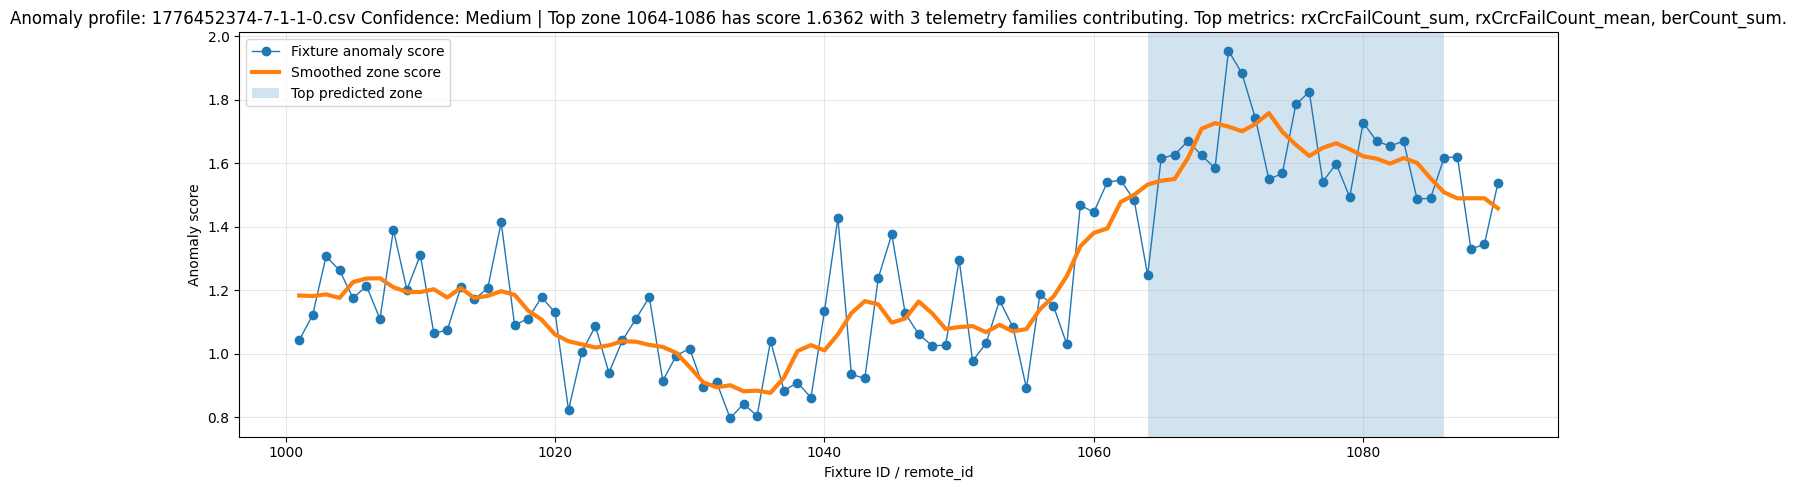

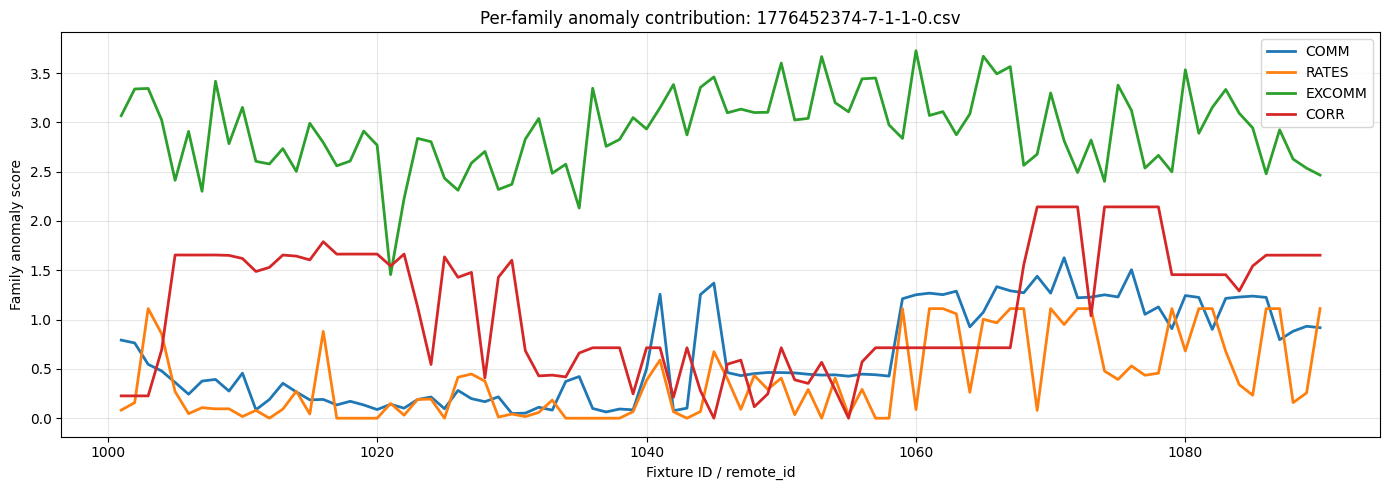

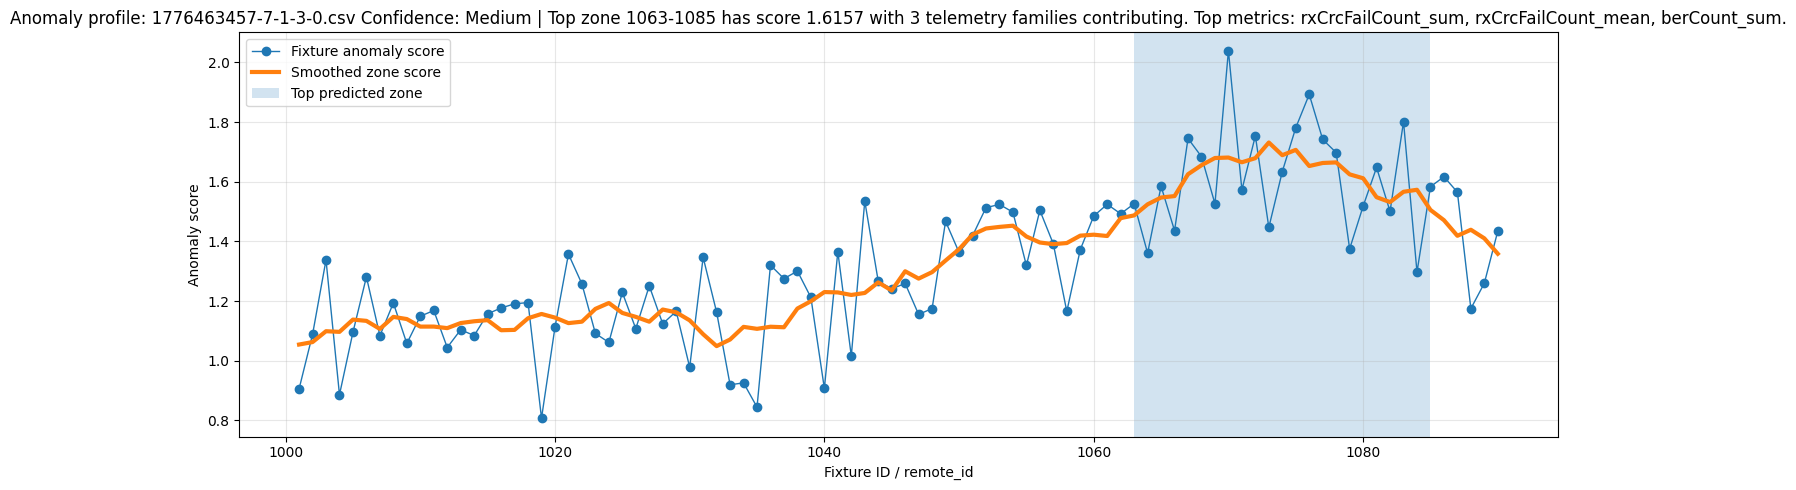

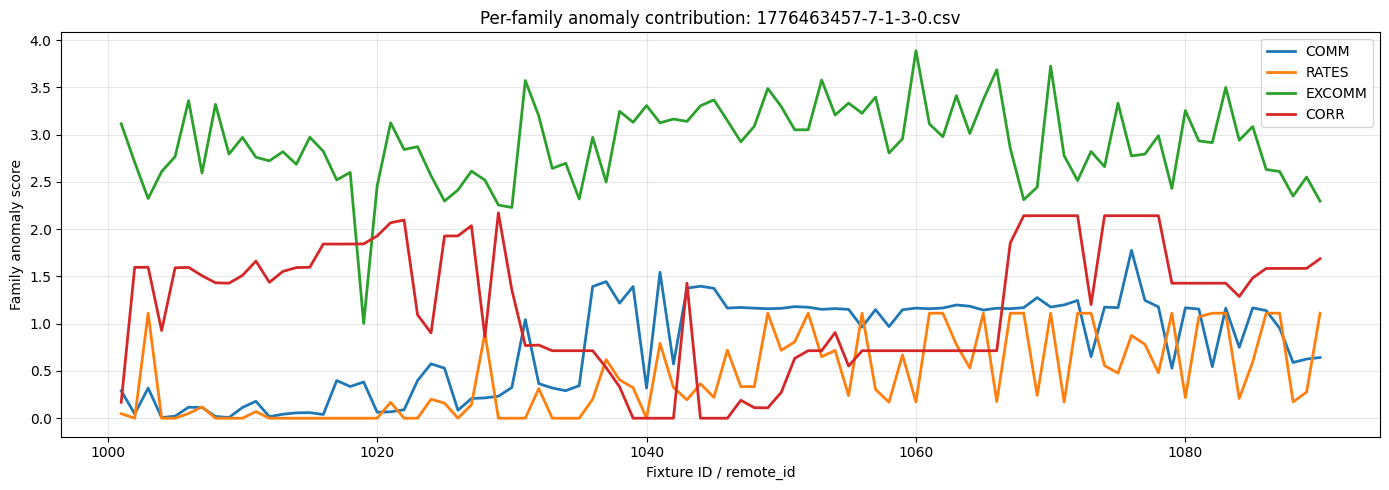

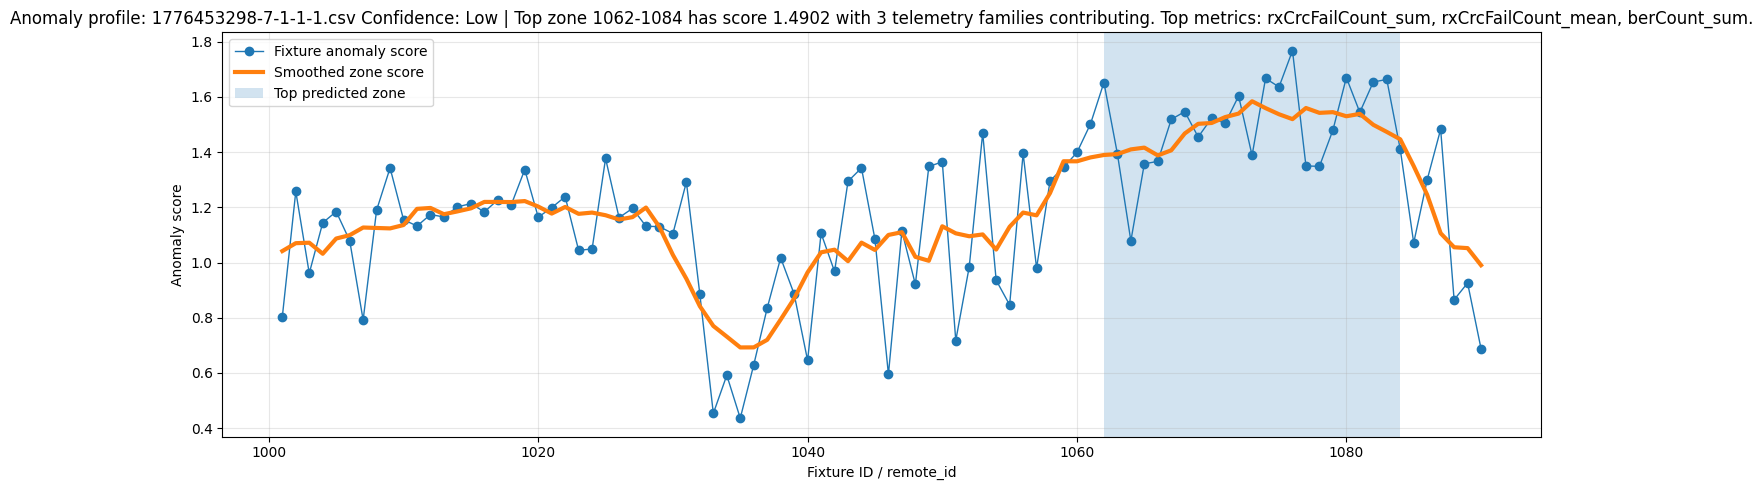

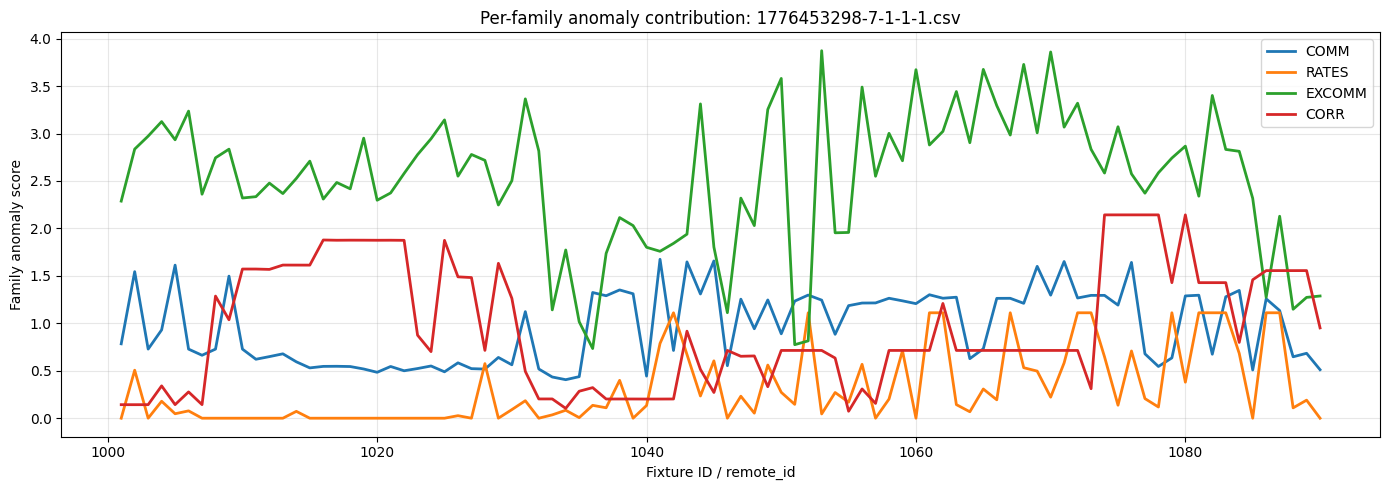

In [13]:
def plot_prediction_profile(file_name, save=True):
    profile = profile_cache.get(file_name)
    if profile is None:
        profile = scored_fixture_df[scored_fixture_df["file_name"] == file_name].sort_values("remote_id").copy()
        profile["smoothed_score"] = profile["combined_fixture_score"].rolling(window=7, center=True, min_periods=1).mean()
    pred = scenario_predictions[scenario_predictions["file_name"] == file_name].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(profile["remote_id"], profile["combined_fixture_score"], marker="o", linewidth=1, label="Fixture anomaly score")
    ax.plot(profile["remote_id"], profile["smoothed_score"], linewidth=3, label="Smoothed zone score")
    if pd.notna(pred["top_start_fixture"]) and pd.notna(pred["top_end_fixture"]):
        ax.axvspan(int(pred["top_start_fixture"]), int(pred["top_end_fixture"]), alpha=0.2, label="Top predicted zone")
    ax.set_title(f"Anomaly profile: {file_name} Confidence: {pred['top_confidence']} | {pred['evidence_summary']}")
    ax.set_xlabel("Fixture ID / remote_id")
    ax.set_ylabel("Anomaly score")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save:
        fig.savefig(PRED_PLOTS_DIR / f"{Path(file_name).stem}_anomaly_profile.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_family_contributions(file_name, save=True):
    profile = scored_fixture_df[scored_fixture_df["file_name"] == file_name].sort_values("remote_id")
    fig, ax = plt.subplots(figsize=(14, 5))
    for fam in FAMILY_FEATURES:
        ax.plot(profile["remote_id"], profile[f"{fam}_score"], linewidth=2, label=fam)
    ax.set_title(f"Per-family anomaly contribution: {file_name}")
    ax.set_xlabel("Fixture ID / remote_id")
    ax.set_ylabel("Family anomaly score")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save:
        fig.savefig(PRED_PLOTS_DIR / f"{Path(file_name).stem}_family_contributions.png", dpi=150, bbox_inches="tight")
    plt.show()

example_files = scenario_predictions.sort_values("top_zone_score", ascending=False)["file_name"].head(3).tolist()
for fn in example_files:
    plot_prediction_profile(fn)
    plot_family_contributions(fn)


## 8. Evaluation: join labels only here

Ground-truth labels are joined only in this section, after predictions have already been created.


In [14]:
evaluation_df = scenario_predictions.merge(
    metadata_df[["file_name", "run_id", "faultLocation", "faultResistance"]],
    on="file_name", how="left"
)
evaluation_df["is_no_fault"] = evaluation_df["faultLocation"] == 0
evaluation_df["has_predicted_zone"] = evaluation_df["top_start_fixture"].notna()
evaluation_df["zone_midpoint"] = (evaluation_df["top_start_fixture"].astype(float) + evaluation_df["top_end_fixture"].astype(float)) / 2
evaluation_df.to_csv(OUTPUTS_DIR / "evaluation_predictions_with_labels.csv", index=False)
evaluation_df.head()


,file_name,predicted_zones,top_start_fixture,top_end_fixture,top_zone_score,top_confidence,confidence_per_zone,top_supporting_metrics,evidence_summary,run_id,faultLocation,faultResistance,is_no_fault,has_predicted_zone,zone_midpoint
0,1776350717-7-1-0-0.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.2516,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...,EFD_T0001,0,0,True,False,NaN
1,1776351640-7-1-1-0.csv,"[{""start_fixture"": 1009, ""end_fixture"": 1021, ...",1009.0,1021.0,1.1507,Low,"[""Low"", ""Low"", ""Low""]","[""rxCrcFailCount_sum"", ""rxCrcFailCount_mean"", ...",Top zone 1009-1021 has score 1.1507 with 2 tel...,EFD_T0001,1,0,False,True,1015.0
2,1776352564-7-1-1-1.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.6574,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...,EFD_T0001,1,1,False,False,NaN
3,1776353487-7-1-1-2.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.7229,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...,EFD_T0001,1,2,False,False,NaN
4,1776354410-7-1-1-4.csv,"[{""start_fixture"": null, ""end_fixture"": null, ...",NaN,NaN,0.6916,Uncertain,"[""Uncertain""]",[],No localized spatial anomaly exceeded the mini...,EFD_T0001,1,4,False,False,NaN


In [15]:
summary_rows = []
for group_cols in [["faultLocation"], ["faultResistance"], ["run_id"], ["faultLocation", "faultResistance"], ["run_id", "faultLocation"]]:
    grouped = evaluation_df.groupby(group_cols, dropna=False)
    for key, g in grouped:
        key_tuple = key if isinstance(key, tuple) else (key,)
        row = {col: val for col, val in zip(group_cols, key_tuple)}
        row.update({
            "n_scenarios": len(g),
            "mean_top_zone_score": g["top_zone_score"].mean(),
            "median_top_zone_score": g["top_zone_score"].median(),
            "mean_zone_midpoint": g["zone_midpoint"].mean(),
            "std_zone_midpoint": g["zone_midpoint"].std(),
            "high_confidence_rate": (g["top_confidence"] == "High").mean(),
            "uncertain_rate": (g["top_confidence"] == "Uncertain").mean(),
        })
        row["grouping"] = "+".join(group_cols)
        summary_rows.append(row)

evaluation_summary = pd.DataFrame(summary_rows)
evaluation_summary.to_csv(OUTPUTS_DIR / "evaluation_summary.csv", index=False)
evaluation_summary.head(20)


,faultLocation,n_scenarios,mean_top_zone_score,median_top_zone_score,mean_zone_midpoint,std_zone_midpoint,high_confidence_rate,uncertain_rate,grouping,faultResistance,run_id
0,0.0,12,0.286900,0.27705,NaN,NaN,0.0,1.000000,faultLocation,NaN,NaN
1,1.0,17,0.873312,0.74030,1046.812500,32.738070,0.0,0.705882,faultLocation,NaN,NaN
2,2.0,17,0.876388,0.79210,1047.350000,38.970822,0.0,0.529412,faultLocation,NaN,NaN
3,3.0,17,0.905165,0.77800,1050.350000,27.576208,0.0,0.588235,faultLocation,NaN,NaN
4,4.0,17,0.830447,0.72330,1057.375000,26.426110,0.0,0.529412,faultLocation,NaN,NaN
5,NaN,24,0.794833,0.78365,1051.291667,31.336486,0.0,0.500000,faultResistance,0.0,NaN
6,NaN,12,0.885200,0.80910,1053.214286,27.693045,0.0,0.500000,faultResistance,1.0,NaN
7,NaN,12,0.773417,0.72975,1055.500000,31.984371,0.0,0.833333,faultResistance,2.0,NaN
8,NaN,4,0.726425,0.73150,1017.000000,0.707107,0.0,1.000000,faultResistance,3.0,NaN
9,NaN,12,0.757025,0.69680,1055.100000,35.856310,0.0,0.666667,faultResistance,4.0,NaN


### Evaluation plots

Because true physical coordinates for `faultLocation` codes are hidden, we evaluate whether scenarios with the same location code produce consistent predicted fixture zones and whether confidence behaves sensibly.


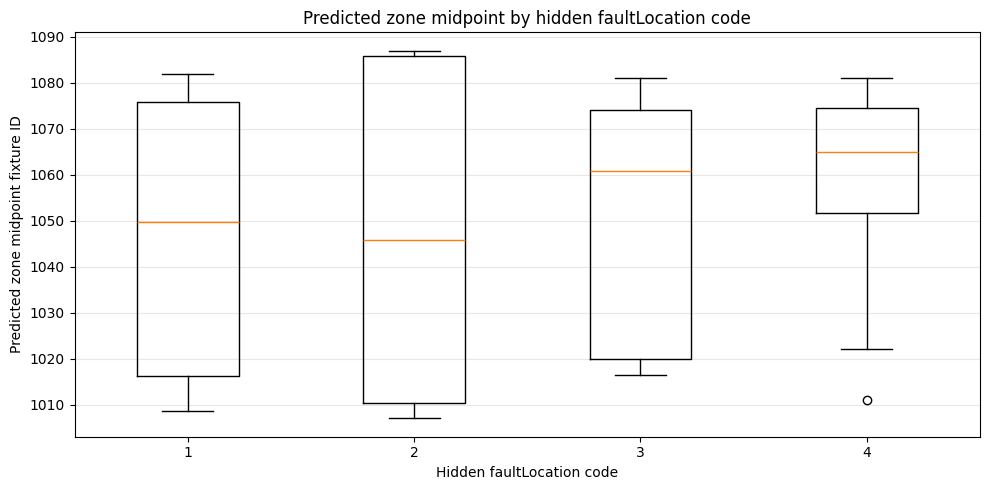

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
faulted = evaluation_df[evaluation_df["faultLocation"] != 0].copy()
if len(faulted) > 0:
    groups = [faulted[faulted["faultLocation"] == loc]["zone_midpoint"].dropna().values for loc in sorted(faulted["faultLocation"].unique())]
    labels = [str(loc) for loc in sorted(faulted["faultLocation"].unique())]
    ax.boxplot(groups, labels=labels)
    ax.set_title("Predicted zone midpoint by hidden faultLocation code")
    ax.set_xlabel("Hidden faultLocation code")
    ax.set_ylabel("Predicted zone midpoint fixture ID")
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(EVAL_PLOTS_DIR / "zone_midpoint_by_faultLocation.png", dpi=150, bbox_inches="tight")
plt.show()


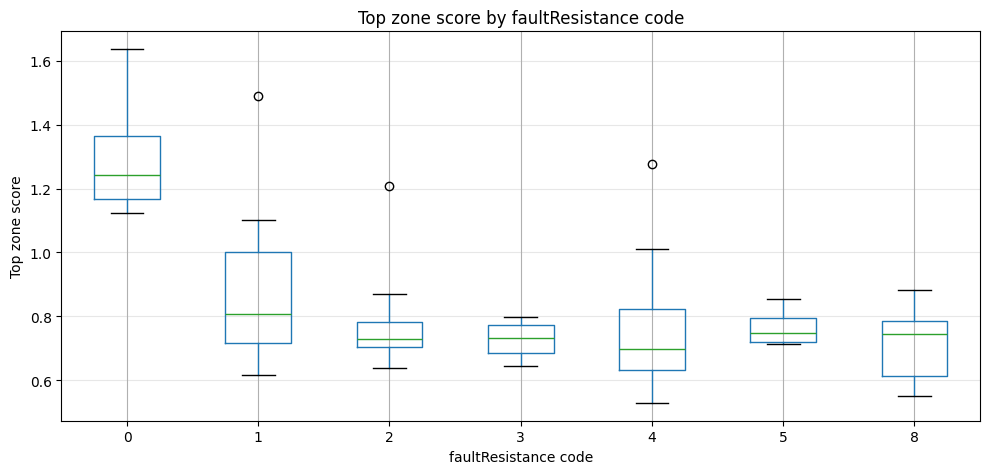

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
faulted = evaluation_df[evaluation_df["faultLocation"] != 0].copy()
if len(faulted) > 0:
    faulted.boxplot(column="top_zone_score", by="faultResistance", ax=ax)
    ax.set_title("Top zone score by faultResistance code")
    ax.set_xlabel("faultResistance code")
    ax.set_ylabel("Top zone score")
    plt.suptitle("")
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(EVAL_PLOTS_DIR / "top_zone_score_by_faultResistance.png", dpi=150, bbox_inches="tight")
plt.show()


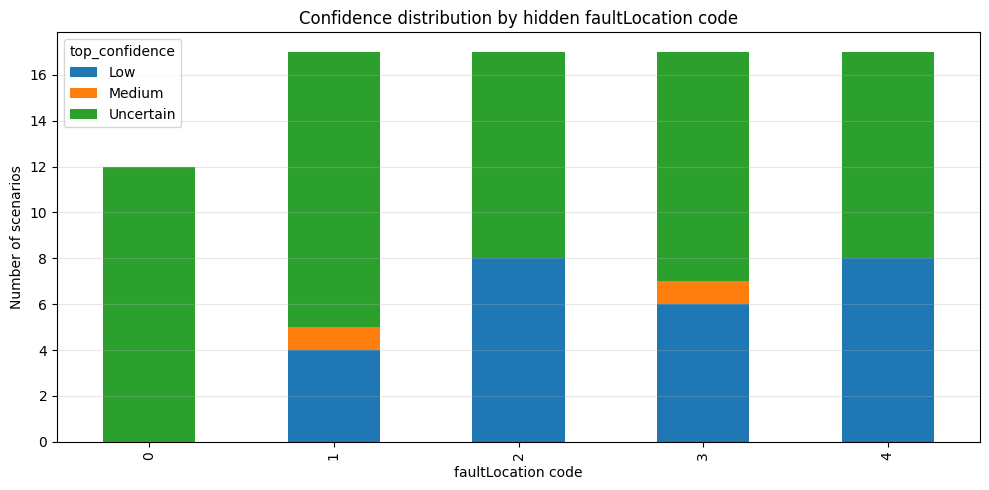

top_confidence,Low,Medium,Uncertain
faultLocation,,,
0,0.0,0.0,12.0
1,4.0,1.0,12.0
2,8.0,0.0,9.0
3,6.0,1.0,10.0
4,8.0,0.0,9.0


In [18]:
confidence_counts = evaluation_df.groupby(["faultLocation", "top_confidence"]).size().reset_index(name="n")
confidence_pivot = confidence_counts.pivot(index="faultLocation", columns="top_confidence", values="n").fillna(0)
confidence_pivot.to_csv(OUTPUTS_DIR / "confidence_summary_by_location.csv")

fig, ax = plt.subplots(figsize=(10, 5))
confidence_pivot.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Confidence distribution by hidden faultLocation code")
ax.set_xlabel("faultLocation code")
ax.set_ylabel("Number of scenarios")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(EVAL_PLOTS_DIR / "confidence_by_faultLocation.png", dpi=150, bbox_inches="tight")
plt.show()
confidence_pivot


## 9. Scenario × predicted zone heatmap

Rows are scenarios and columns are fixtures. Values are smoothed anomaly scores.


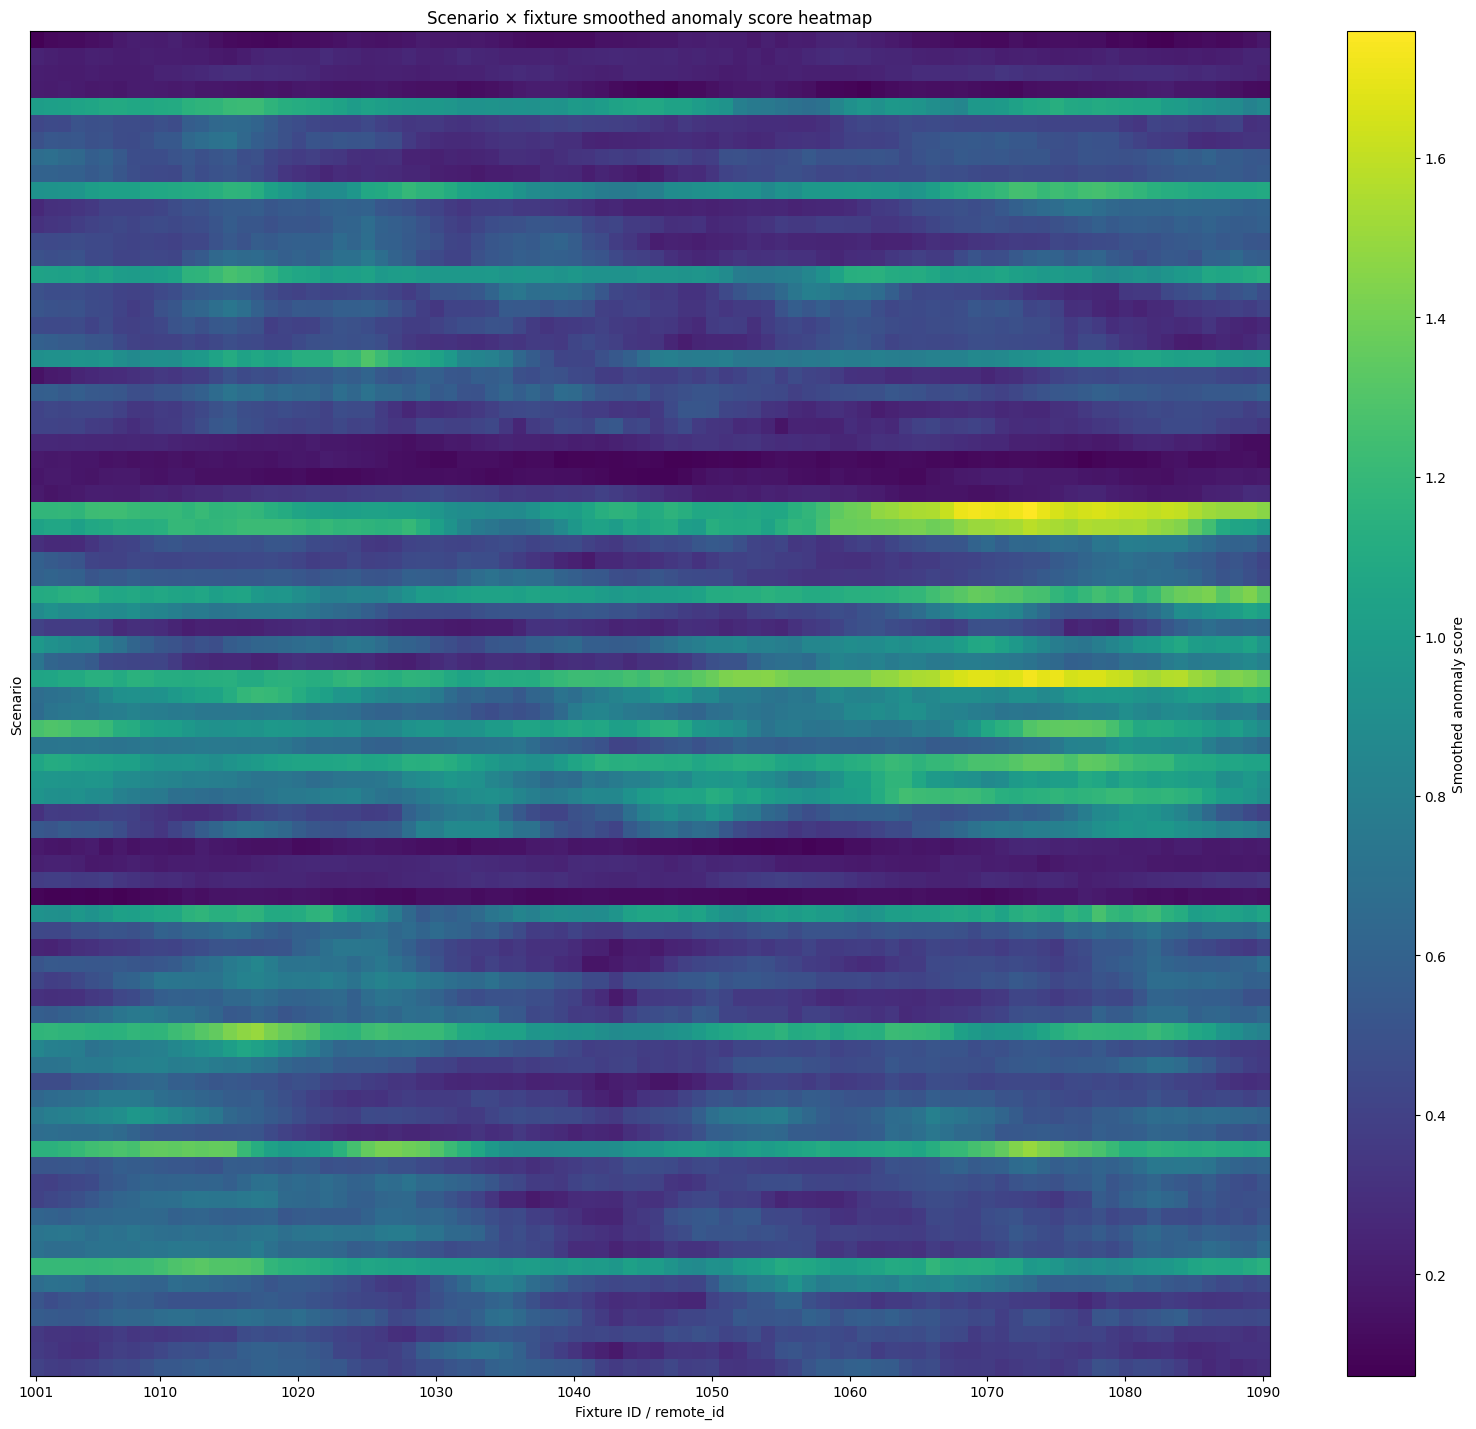

In [19]:
heat_rows = []
heat_index = []
ordered_eval = evaluation_df.sort_values(["run_id", "faultLocation", "faultResistance", "file_name"])
for _, row in ordered_eval.iterrows():
    fn = row["file_name"]
    profile = profile_cache.get(fn)
    if profile is None:
        profile = scored_fixture_df[scored_fixture_df["file_name"] == fn].sort_values("remote_id").copy()
        profile["smoothed_score"] = profile["combined_fixture_score"].rolling(window=7, center=True, min_periods=1).mean()
    heat_rows.append(profile.set_index("remote_id")["smoothed_score"].reindex(range(1001, 1091)).values)
    heat_index.append(f"{row['run_id']} | L{row['faultLocation']} | R{row['faultResistance']} | {fn[:10]}")

heatmap_df = pd.DataFrame(heat_rows, index=heat_index, columns=list(range(1001, 1091)))
heatmap_df.to_csv(OUTPUTS_DIR / "scenario_fixture_score_heatmap_matrix.csv")

fig, ax = plt.subplots(figsize=(16, max(6, len(heatmap_df) * 0.18)))
im = ax.imshow(heatmap_df.values, aspect="auto", interpolation="nearest")
ax.set_title("Scenario × fixture smoothed anomaly score heatmap")
ax.set_xlabel("Fixture ID / remote_id")
ax.set_ylabel("Scenario")
ax.set_xticks(np.linspace(0, 89, 10).astype(int))
ax.set_xticklabels([heatmap_df.columns[i] for i in np.linspace(0, 89, 10).astype(int)])
if len(heatmap_df) <= 60:
    ax.set_yticks(np.arange(len(heatmap_df)))
    ax.set_yticklabels(heatmap_df.index, fontsize=7)
else:
    ax.set_yticks([])
fig.colorbar(im, ax=ax, label="Smoothed anomaly score")
plt.tight_layout()
fig.savefig(EVAL_PLOTS_DIR / "scenario_fixture_score_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Final output files

In [20]:
print("Saved output CSVs:")
for p in sorted(OUTPUTS_DIR.glob("*.csv")):
    print(" -", p)
print("
Prediction plots:")
for p in sorted(PRED_PLOTS_DIR.glob("*.png"))[:10]:
    print(" -", p)
print("
Evaluation plots:")
for p in sorted(EVAL_PLOTS_DIR.glob("*.png")):
    print(" -", p)


SyntaxError: unterminated string literal (detected at line 4) (4130088146.py, line 4)

## Notes for interpretation

- The prediction path uses telemetry-derived anomaly scores only.
- `faultLocation` and `faultResistance` are joined only in the evaluation section.
- The model predicts ranked fixture-ID zones, not a standard classification label.
- Exact physical coordinates for location codes 1–4 are hidden, so evaluation emphasizes spatial consistency and confidence behavior.
